<a href="https://colab.research.google.com/github/SANGHATI23/sam-brats-robustness-audit/blob/main/04_MedReasoner_Controlled_Counterfactual_QC_Qwen25VL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — Runtime and safe dependency installation
import sys, platform, subprocess, torch
print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError('GPU runtime required.')
print('GPU:', torch.cuda.get_device_name(0))
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

# Do not upgrade NumPy/Pandas/SciPy/Scikit-learn inside a running Colab session.
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q', '--upgrade',
    'transformers>=4.49.0,<5', 'accelerate>=1.2.0', 'qwen-vl-utils>=0.0.10'
], check=True)
print('VLM dependencies installed.')

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
GPU memory: 79.3 GB
VLM dependencies installed.


In [2]:
# CELL 2 — Imports and configuration
import os, re, json, time, random, gc
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm
from IPython.display import display
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, roc_curve, precision_recall_curve
)
from scipy.stats import spearmanr
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

SEED=2026
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
MODEL_ID='Qwen/Qwen2.5-VL-7B-Instruct'
EXPERIMENT_ID='04_counterfactual_qc_qwen25vl7b'
PROMPT_VERSION='counterfactual_v1.0'
BASE_CASES_PER_DOMAIN=15
CONDITIONS=['CLEAN','SHIFT','OVERSEGMENTATION','UNDERSEGMENTATION','PARTIAL_MISSING','WRONG_REGION']
OVERWRITE_EXISTING=False
MAX_CASES=None
MIN_PIXELS=256*28*28
MAX_PIXELS=1024*28*28
MAX_NEW_TOKENS=180
DOMAIN_TARGET={
    'brain_mri': {'domain_text':'brain MRI','target_text':'brain tumor'},
    'kidney_ct': {'domain_text':'kidney CT','target_text':'kidney tumor'},
    'histopathology': {'domain_text':'H&E histopathology','target_text':'cell nuclei'}
}
print('Experiment:', EXPERIMENT_ID)
print('Planned images:', BASE_CASES_PER_DOMAIN*3*len(CONDITIONS))

Experiment: 04_counterfactual_qc_qwen25vl7b
Planned images: 270


In [3]:
# CELL 3 — Mount Drive and select 45 base cases
from google.colab import drive
DRIVE=Path('/content/drive')
if not (DRIVE/'MyDrive').exists():
    drive.mount(str(DRIVE), force_remount=False)
ROOT=DRIVE/'MyDrive'/'MedReasoner_SAM_2026'
MANIFEST_DIR=ROOT/'01_manifests'
CF_ROOT=ROOT/'04_counterfactual_masks'
OUTPUT_DIR=ROOT/'03_vlm_outputs'
EVAL_DIR=ROOT/'05_evaluation'
FIG_DIR=ROOT/'06_figures'
LOG_DIR=ROOT/'logs'
for p in [CF_ROOT,OUTPUT_DIR,EVAL_DIR,FIG_DIR,LOG_DIR]: p.mkdir(parents=True,exist_ok=True)

assets=pd.read_csv(MANIFEST_DIR/'medreasoner_vlm_asset_manifest.csv')
need={'benchmark_id','domain','record_id','case_id','image_path','gt_mask_internal_only','stored_dice'}
missing=sorted(need-set(assets.columns))
if missing: raise ValueError(f'Missing columns: {missing}')

for col in ['image_path','gt_mask_internal_only']:
    bad=[p for p in assets[col].astype(str) if not Path(p).exists()]
    if bad: raise FileNotFoundError(f'{len(bad)} missing files in {col}; example: {bad[0]}')

def select_unique(df,n,seed):
    d=df.sample(frac=1.0,random_state=seed).copy()
    u=d.drop_duplicates('case_id',keep='first')
    if len(u)>=n: return u.head(n).copy()
    remain=d[~d['benchmark_id'].isin(u['benchmark_id'])]
    return pd.concat([u,remain.head(n-len(u))],ignore_index=True)

parts=[]
for i,domain in enumerate(['brain_mri','kidney_ct','histopathology']):
    parts.append(select_unique(assets[assets['domain']==domain],BASE_CASES_PER_DOMAIN,SEED+i))
base=pd.concat(parts,ignore_index=True)[['benchmark_id','domain','record_id','case_id','image_path','gt_mask_internal_only','stored_dice']].copy()
base.insert(0,'base_id',[f'BASE_{i:03d}' for i in range(1,len(base)+1)])
base.to_csv(CF_ROOT/'counterfactual_base_cases.csv',index=False)
print('Base cases:',len(base))
display(base.groupby('domain').size().reset_index(name='n'))

Mounted at /content/drive
Base cases: 45


,domain,n
0,brain_mri,15
1,histopathology,15
2,kidney_ct,15


In [4]:
# CELL 4 — Image/mask helpers and deterministic counterfactual transforms
def read_rgb(path):
    x=cv2.imread(str(path),cv2.IMREAD_COLOR)
    if x is None: raise FileNotFoundError(path)
    return cv2.cvtColor(x,cv2.COLOR_BGR2RGB)

def read_mask(path):
    x=cv2.imread(str(path),cv2.IMREAD_GRAYSCALE)
    if x is None: raise FileNotFoundError(path)
    return (x>0).astype(np.uint8)

def save_rgb(path,img):
    Path(path).parent.mkdir(parents=True,exist_ok=True)
    cv2.imwrite(str(path),cv2.cvtColor(img.astype(np.uint8),cv2.COLOR_RGB2BGR))

def save_mask(path,m):
    Path(path).parent.mkdir(parents=True,exist_ok=True)
    cv2.imwrite(str(path),(m>0).astype(np.uint8)*255)

def dice_iou(a,b):
    a=np.asarray(a)>0; b=np.asarray(b)>0
    inter=np.logical_and(a,b).sum(); union=np.logical_or(a,b).sum()
    return float(2*inter/(a.sum()+b.sum()+1e-8)), float(inter/(union+1e-8))

def bbox(m):
    ys,xs=np.where(m>0)
    return None if len(xs)==0 else (int(xs.min()),int(ys.min()),int(xs.max()),int(ys.max()))

def translate(m,dx,dy):
    h,w=m.shape; M=np.float32([[1,0,dx],[0,1,dy]])
    return (cv2.warpAffine(m.astype(np.uint8),M,(w,h),flags=cv2.INTER_NEAREST,borderMode=cv2.BORDER_CONSTANT,borderValue=0)>0).astype(np.uint8)

def overlay(img,m,alpha=.35):
    out=img.astype(np.float32).copy(); mask=m>0; red=np.array([255,0,0],dtype=np.float32)
    out[mask]=(1-alpha)*out[mask]+alpha*red; out=np.clip(out,0,255).astype(np.uint8)
    cnt,_=cv2.findContours((mask.astype(np.uint8)*255),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(out,cnt,-1,(255,0,0),2)
    return out

def odd(x):
    x=max(3,int(round(x))); return x if x%2 else x+1

def shift_mask(m):
    b=bbox(m)
    if b is None: return m.copy(),{}
    x0,y0,x1,y1=b; bw=max(1,x1-x0+1); bh=max(1,y1-y0+1); cand=[]
    for frac in [.35,.5,.7,.9]:
        for sx,sy in [(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)]:
            dx=int(round(sx*frac*bw)); dy=int(round(sy*frac*bh)); x=translate(m,dx,dy)
            retain=x.sum()/max(m.sum(),1); d,_=dice_iou(x,m)
            if retain>=.80: cand.append((d,-retain,dx,dy,x))
    cand.sort(key=lambda z:(z[0],z[1]))
    d,nr,dx,dy,x=cand[0]
    return x,{'dx':dx,'dy':dy,'retention':float(-nr)}

def dilate_mask(m):
    b=bbox(m)
    if b is None: return m.copy(),{}
    x0,y0,x1,y1=b; scale=max(3,min(x1-x0+1,y1-y0+1)); best=m.copy(); meta={}
    for frac in [.05,.08,.12,.16]:
        k=odd(scale*frac); ker=np.ones((k,k),np.uint8)
        for it in [1,2,3]:
            x=(cv2.dilate(m,ker,iterations=it)>0).astype(np.uint8); d,_=dice_iou(x,m)
            best=x; meta={'kernel':k,'iterations':it,'area_ratio':float(x.sum()/max(m.sum(),1))}
            if d<=.70: return x,meta
    return best,meta

def erode_mask(m):
    b=bbox(m)
    if b is None: return m.copy(),{}
    x0,y0,x1,y1=b; scale=max(3,min(x1-x0+1,y1-y0+1)); best=m.copy(); meta={}
    for frac in [.04,.06,.08,.10,.14]:
        k=odd(scale*frac); ker=np.ones((k,k),np.uint8)
        for it in [1,2,3]:
            x=(cv2.erode(m,ker,iterations=it)>0).astype(np.uint8)
            if x.sum()==0: continue
            d,_=dice_iou(x,m); best=x; meta={'kernel':k,'iterations':it,'area_ratio':float(x.sum()/max(m.sum(),1))}
            if d<=.70: return x,meta
    return best,meta

def partial_missing(m):
    ys,xs=np.where(m>0); cand=[]
    for q in np.quantile(xs,[.35,.4,.45,.55,.6,.65]):
        for side in ['left','right']:
            x=m.copy(); x[:,int(q):]=0 if side=='left' else x[:,int(q):]
            if side=='right': x[:,:int(q)]=0
            frac=x.sum()/max(m.sum(),1)
            if x.sum()>0: cand.append((abs(frac-.40),frac,f'x_{side}',int(q),x))
    for q in np.quantile(ys,[.35,.4,.45,.55,.6,.65]):
        for side in ['top','bottom']:
            x=m.copy(); x[int(q):,:]=0 if side=='top' else x[int(q):,:]
            if side=='bottom': x[:int(q),:]=0
            frac=x.sum()/max(m.sum(),1)
            if x.sum()>0: cand.append((abs(frac-.40),frac,f'y_{side}',int(q),x))
    cand.sort(key=lambda z:z[0]); _,frac,cut,q,x=cand[0]
    return x,{'retained_fraction':float(frac),'cut':cut,'coordinate':q}

def wrong_region(m):
    h,w=m.shape; b=bbox(m)
    if b is None: return m.copy(),{}
    x0,y0,x1,y1=b; cx=(x0+x1)/2; cy=(y0+y1)/2; cand=[]
    for tx,ty in [(.15*w,.15*h),(.85*w,.15*h),(.15*w,.85*h),(.85*w,.85*h),(.5*w,.15*h),(.5*w,.85*h),(.15*w,.5*h),(.85*w,.5*h)]:
        dx=int(round(tx-cx)); dy=int(round(ty-cy)); x=translate(m,dx,dy)
        retain=x.sum()/max(m.sum(),1); d,_=dice_iou(x,m)
        if retain>=.70: cand.append((d,-retain,dx,dy,x))
    if not cand: return shift_mask(m)
    cand.sort(key=lambda z:(z[0],z[1])); d,nr,dx,dy,x=cand[0]
    return x,{'dx':dx,'dy':dy,'retention':float(-nr)}

TRANSFORMS={
    'CLEAN':lambda m:(m.copy(),{}),
    'SHIFT':shift_mask,
    'OVERSEGMENTATION':dilate_mask,
    'UNDERSEGMENTATION':erode_mask,
    'PARTIAL_MISSING':partial_missing,
    'WRONG_REGION':wrong_region
}
print(list(TRANSFORMS))

['CLEAN', 'SHIFT', 'OVERSEGMENTATION', 'UNDERSEGMENTATION', 'PARTIAL_MISSING', 'WRONG_REGION']


In [6]:
# REPLACEMENT CELL — Robust counterfactual mask transformations

import numpy as np
import cv2


# ---------------------------------------------------------
# Basic utilities
# ---------------------------------------------------------

def dice_iou(a, b):
    a = np.asarray(a) > 0
    b = np.asarray(b) > 0

    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()

    dice = (2.0 * inter) / (a.sum() + b.sum() + 1e-8)
    iou = inter / (union + 1e-8)

    return float(dice), float(iou)


def bbox(mask):
    mask = np.asarray(mask) > 0
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return None

    return (
        int(xs.min()),
        int(ys.min()),
        int(xs.max()),
        int(ys.max())
    )


def translate_mask(mask, dx, dy):
    mask = (np.asarray(mask) > 0).astype(np.uint8)

    h, w = mask.shape

    M = np.float32([
        [1, 0, dx],
        [0, 1, dy]
    ])

    shifted = cv2.warpAffine(
        mask,
        M,
        (w, h),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return (shifted > 0).astype(np.uint8)


def odd_kernel(value, minimum=3):
    k = max(minimum, int(round(value)))

    if k % 2 == 0:
        k += 1

    return k


# ---------------------------------------------------------
# 1. SHIFT
# ---------------------------------------------------------

def shift_mask(mask):

    mask = (np.asarray(mask) > 0).astype(np.uint8)

    b = bbox(mask)

    if b is None:
        raise ValueError("Cannot shift an empty mask.")

    x0, y0, x1, y1 = b

    bw = max(1, x1 - x0 + 1)
    bh = max(1, y1 - y0 + 1)

    candidates = []

    # Start small, then progressively stronger shifts.
    for frac in [
        0.10,
        0.15,
        0.20,
        0.30,
        0.40,
        0.50,
        0.70,
        0.90
    ]:

        directions = [
            (1, 0),
            (-1, 0),
            (0, 1),
            (0, -1),
            (1, 1),
            (1, -1),
            (-1, 1),
            (-1, -1)
        ]

        for sx, sy in directions:

            dx = int(round(sx * frac * bw))
            dy = int(round(sy * frac * bh))

            # Guarantee actual displacement.
            if sx != 0 and dx == 0:
                dx = sx

            if sy != 0 and dy == 0:
                dy = sy

            shifted = translate_mask(mask, dx, dy)

            if shifted.sum() == 0:
                continue

            retention = (
                shifted.sum()
                / max(mask.sum(), 1)
            )

            d, _ = dice_iou(
                shifted,
                mask
            )

            candidates.append({
                "mask": shifted,
                "dice": float(d),
                "retention": float(retention),
                "dx": int(dx),
                "dy": int(dy)
            })


    # Extreme edge-mask fallback.
    if len(candidates) == 0:

        for dx, dy in [
            (1, 0),
            (-1, 0),
            (0, 1),
            (0, -1)
        ]:

            shifted = translate_mask(
                mask,
                dx,
                dy
            )

            if shifted.sum() > 0:

                retention = (
                    shifted.sum()
                    / max(mask.sum(), 1)
                )

                d, _ = dice_iou(
                    shifted,
                    mask
                )

                return shifted, {
                    "dx": int(dx),
                    "dy": int(dy),
                    "retention": float(retention),
                    "reference_dice": float(d),
                    "fallback": True
                }

        raise RuntimeError(
            "Unable to generate non-empty shifted mask."
        )


    # Prefer masks retaining >=80% original area.
    preferred = [
        c for c in candidates
        if c["retention"] >= 0.80
    ]


    if preferred:

        # Strongest corruption among well-preserved masks.
        best = min(
            preferred,
            key=lambda c: (
                c["dice"],
                -c["retention"]
            )
        )

        fallback = False

    else:

        # Edge masks may not permit 80% retention.
        # Keep the best-preserved candidates first.
        max_retention = max(
            c["retention"]
            for c in candidates
        )

        near_best = [
            c for c in candidates
            if c["retention"]
            >= max_retention - 0.05
        ]

        best = min(
            near_best,
            key=lambda c: c["dice"]
        )

        fallback = True


    return best["mask"], {
        "dx": best["dx"],
        "dy": best["dy"],
        "retention": best["retention"],
        "reference_dice": best["dice"],
        "fallback": fallback
    }


# ---------------------------------------------------------
# 2. OVERSEGMENTATION
# ---------------------------------------------------------

def dilate_mask(mask):

    mask = (np.asarray(mask) > 0).astype(np.uint8)

    b = bbox(mask)

    if b is None:
        raise ValueError(
            "Cannot dilate empty mask."
        )

    x0, y0, x1, y1 = b

    scale = max(
        3,
        min(
            x1 - x0 + 1,
            y1 - y0 + 1
        )
    )

    candidates = []

    for frac in [
        0.04,
        0.06,
        0.08,
        0.10,
        0.14,
        0.18
    ]:

        k = odd_kernel(
            scale * frac
        )

        kernel = np.ones(
            (k, k),
            dtype=np.uint8
        )

        for iterations in [1, 2, 3]:

            cand = cv2.dilate(
                mask,
                kernel,
                iterations=iterations
            )

            cand = (
                cand > 0
            ).astype(np.uint8)

            d, _ = dice_iou(
                cand,
                mask
            )

            area_ratio = (
                cand.sum()
                / max(mask.sum(), 1)
            )

            candidates.append({
                "mask": cand,
                "dice": float(d),
                "kernel": int(k),
                "iterations": int(iterations),
                "area_ratio": float(area_ratio)
            })


    # Prefer clearly corrupted but non-extreme output.
    eligible = [
        c for c in candidates
        if c["dice"] <= 0.75
    ]

    if eligible:
        best = min(
            eligible,
            key=lambda c: abs(
                c["dice"] - 0.60
            )
        )
    else:
        best = min(
            candidates,
            key=lambda c: c["dice"]
        )


    return best["mask"], {
        "kernel": best["kernel"],
        "iterations": best["iterations"],
        "area_ratio": best["area_ratio"],
        "reference_dice": best["dice"]
    }


# ---------------------------------------------------------
# 3. UNDERSEGMENTATION
# ---------------------------------------------------------

def erode_mask(mask):

    mask = (
        np.asarray(mask) > 0
    ).astype(np.uint8)

    b = bbox(mask)

    if b is None:
        raise ValueError(
            "Cannot erode empty mask."
        )

    x0, y0, x1, y1 = b

    scale = max(
        3,
        min(
            x1 - x0 + 1,
            y1 - y0 + 1
        )
    )

    candidates = []

    for frac in [
        0.03,
        0.04,
        0.05,
        0.06,
        0.08,
        0.10,
        0.14
    ]:

        k = odd_kernel(
            scale * frac
        )

        kernel = np.ones(
            (k, k),
            dtype=np.uint8
        )

        for iterations in [1, 2, 3]:

            cand = cv2.erode(
                mask,
                kernel,
                iterations=iterations
            )

            cand = (
                cand > 0
            ).astype(np.uint8)

            # Never permit completely empty mask.
            if cand.sum() == 0:
                continue

            d, _ = dice_iou(
                cand,
                mask
            )

            area_ratio = (
                cand.sum()
                / max(mask.sum(), 1)
            )

            candidates.append({
                "mask": cand,
                "dice": float(d),
                "kernel": int(k),
                "iterations": int(iterations),
                "area_ratio": float(area_ratio)
            })


    if len(candidates) == 0:

        # Very tiny objects can disappear under erosion.
        # Use a conservative one-pixel boundary erosion.
        kernel = np.ones(
            (3, 3),
            dtype=np.uint8
        )

        cand = cv2.erode(
            mask,
            kernel,
            iterations=1
        )

        cand = (
            cand > 0
        ).astype(np.uint8)

        if cand.sum() == 0:
            # Fallback to partial removal instead.
            return partial_missing(mask)

        d, _ = dice_iou(
            cand,
            mask
        )

        return cand, {
            "kernel": 3,
            "iterations": 1,
            "area_ratio": float(
                cand.sum()
                / max(mask.sum(), 1)
            ),
            "reference_dice": float(d),
            "fallback": True
        }


    eligible = [
        c for c in candidates
        if c["dice"] <= 0.75
    ]

    if eligible:
        best = min(
            eligible,
            key=lambda c: abs(
                c["dice"] - 0.60
            )
        )
    else:
        best = min(
            candidates,
            key=lambda c: c["dice"]
        )


    return best["mask"], {
        "kernel": best["kernel"],
        "iterations": best["iterations"],
        "area_ratio": best["area_ratio"],
        "reference_dice": best["dice"]
    }


# ---------------------------------------------------------
# 4. PARTIAL MISSING
# ---------------------------------------------------------

def partial_missing(mask):

    mask = (
        np.asarray(mask) > 0
    ).astype(np.uint8)

    ys, xs = np.where(
        mask > 0
    )

    if len(xs) == 0:
        raise ValueError(
            "Cannot cut empty mask."
        )

    candidates = []

    # Target approximately 40% mask retention.
    target_fraction = 0.40

    xcuts = np.unique(
        np.percentile(
            xs,
            [
                25,
                35,
                40,
                45,
                55,
                60,
                65,
                75
            ]
        ).astype(int)
    )

    ycuts = np.unique(
        np.percentile(
            ys,
            [
                25,
                35,
                40,
                45,
                55,
                60,
                65,
                75
            ]
        ).astype(int)
    )


    for q in xcuts:

        left = mask.copy()
        left[:, q:] = 0

        if left.sum() > 0:
            frac = (
                left.sum()
                / max(mask.sum(), 1)
            )

            candidates.append({
                "mask": left,
                "fraction": float(frac),
                "cut": "retain_left",
                "coordinate": int(q)
            })


        right = mask.copy()
        right[:, :q] = 0

        if right.sum() > 0:
            frac = (
                right.sum()
                / max(mask.sum(), 1)
            )

            candidates.append({
                "mask": right,
                "fraction": float(frac),
                "cut": "retain_right",
                "coordinate": int(q)
            })


    for q in ycuts:

        top = mask.copy()
        top[q:, :] = 0

        if top.sum() > 0:
            frac = (
                top.sum()
                / max(mask.sum(), 1)
            )

            candidates.append({
                "mask": top,
                "fraction": float(frac),
                "cut": "retain_top",
                "coordinate": int(q)
            })


        bottom = mask.copy()
        bottom[:q, :] = 0

        if bottom.sum() > 0:
            frac = (
                bottom.sum()
                / max(mask.sum(), 1)
            )

            candidates.append({
                "mask": bottom,
                "fraction": float(frac),
                "cut": "retain_bottom",
                "coordinate": int(q)
            })


    if len(candidates) == 0:
        raise RuntimeError(
            "Could not generate partial-missing mask."
        )


    best = min(
        candidates,
        key=lambda c: abs(
            c["fraction"]
            - target_fraction
        )
    )


    d, _ = dice_iou(
        best["mask"],
        mask
    )


    return best["mask"], {
        "retained_fraction":
            best["fraction"],
        "cut":
            best["cut"],
        "coordinate":
            best["coordinate"],
        "reference_dice":
            float(d)
    }


# ---------------------------------------------------------
# 5. WRONG REGION
# ---------------------------------------------------------

def wrong_region(mask):

    mask = (
        np.asarray(mask) > 0
    ).astype(np.uint8)

    h, w = mask.shape

    b = bbox(mask)

    if b is None:
        raise ValueError(
            "Cannot relocate empty mask."
        )

    x0, y0, x1, y1 = b

    cx = (
        x0 + x1
    ) / 2.0

    cy = (
        y0 + y1
    ) / 2.0


    target_centers = [
        (0.10 * w, 0.10 * h),
        (0.90 * w, 0.10 * h),
        (0.10 * w, 0.90 * h),
        (0.90 * w, 0.90 * h),

        (0.50 * w, 0.10 * h),
        (0.50 * w, 0.90 * h),
        (0.10 * w, 0.50 * h),
        (0.90 * w, 0.50 * h),

        (0.25 * w, 0.25 * h),
        (0.75 * w, 0.25 * h),
        (0.25 * w, 0.75 * h),
        (0.75 * w, 0.75 * h)
    ]


    candidates = []

    for tx, ty in target_centers:

        dx = int(
            round(
                tx - cx
            )
        )

        dy = int(
            round(
                ty - cy
            )
        )

        moved = translate_mask(
            mask,
            dx,
            dy
        )

        if moved.sum() == 0:
            continue

        retention = (
            moved.sum()
            / max(mask.sum(), 1)
        )

        d, _ = dice_iou(
            moved,
            mask
        )

        candidates.append({
            "mask": moved,
            "dice": float(d),
            "retention": float(retention),
            "dx": int(dx),
            "dy": int(dy)
        })


    # Ideal wrong region:
    # nearly full mask retained and virtually no overlap.
    preferred = [
        c for c in candidates
        if (
            c["retention"] >= 0.70
            and c["dice"] <= 0.10
        )
    ]


    if preferred:

        best = min(
            preferred,
            key=lambda c: (
                c["dice"],
                -c["retention"]
            )
        )

        fallback = False

    elif candidates:

        # Prioritize preservation first,
        # then minimize overlap.
        max_retention = max(
            c["retention"]
            for c in candidates
        )

        preserved = [
            c for c in candidates
            if c["retention"]
            >= max_retention - 0.05
        ]

        best = min(
            preserved,
            key=lambda c: c["dice"]
        )

        fallback = True

    else:

        # Edge-case fallback to robust SHIFT.
        moved, meta = shift_mask(mask)

        meta[
            "fallback_from_wrong_region"
        ] = True

        return moved, meta


    return best["mask"], {
        "dx": best["dx"],
        "dy": best["dy"],
        "retention": best["retention"],
        "reference_dice": best["dice"],
        "fallback": fallback
    }


# ---------------------------------------------------------
# Transformation dictionary
# ---------------------------------------------------------

TRANSFORMS = {

    "CLEAN":
        lambda m: (
            (np.asarray(m) > 0).astype(np.uint8).copy(),
            {
                "reference_dice": 1.0,
                "fallback": False
            }
        ),

    "SHIFT":
        shift_mask,

    "OVERSEGMENTATION":
        dilate_mask,

    "UNDERSEGMENTATION":
        erode_mask,

    "PARTIAL_MISSING":
        partial_missing,

    "WRONG_REGION":
        wrong_region
}


print("Counterfactual transformations loaded successfully.")
print("Conditions:", list(TRANSFORMS.keys()))

Counterfactual transformations loaded successfully.
Conditions: ['CLEAN', 'SHIFT', 'OVERSEGMENTATION', 'UNDERSEGMENTATION', 'PARTIAL_MISSING', 'WRONG_REGION']


In [7]:
# CELL 5 — Build the 270 counterfactual assets
rows=[]; counter=1
for _,r in tqdm(base.iterrows(),total=len(base),desc='Building counterfactual cases'):
    img=read_rgb(r['image_path']); gt=read_mask(r['gt_mask_internal_only'])
    if gt.sum()==0: raise ValueError(f"Empty GT: {r['benchmark_id']}")
    for condition in CONDITIONS:
        cand,meta=TRANSFORMS[condition](gt)
        if cand.sum()==0: raise ValueError(f"Empty corruption: {r['benchmark_id']} {condition}")
        d,j=dice_iou(cand,gt); cid=f'CF_{counter:04d}'; counter+=1
        folder=CF_ROOT/'cases'/cid; folder.mkdir(parents=True,exist_ok=True)
        image_out=folder/'image.png'; mask_out=folder/'candidate_mask.png'; ov_out=folder/'vlm_overlay.png'
        save_rgb(image_out,img); save_mask(mask_out,cand); save_rgb(ov_out,overlay(img,cand))
        rows.append({
            'cf_id':cid,'base_id':r['base_id'],'source_benchmark_id':r['benchmark_id'],'domain':r['domain'],
            'record_id':r['record_id'],'case_id':r['case_id'],'condition':condition,'is_corrupted':condition!='CLEAN',
            'reference_dice':d,'reference_iou':j,'dice_degradation':1.0-d,
            'area_ratio_vs_reference':float(cand.sum()/max(gt.sum(),1)),
            'image_path':str(image_out),'candidate_mask_path':str(mask_out),'vlm_overlay_path':str(ov_out),
            'transform_metadata':json.dumps(meta)
        })
cf_labels=pd.DataFrame(rows)
CF_LABELS_PATH=CF_ROOT/'counterfactual_hidden_labels.csv'
cf_labels.to_csv(CF_LABELS_PATH,index=False)
print('Counterfactual cases:',len(cf_labels))
display(cf_labels.groupby(['domain','condition']).size().reset_index(name='n'))
display(cf_labels.groupby('condition')['reference_dice'].agg(['count','mean','std','min','max']).reset_index())

clean=cf_labels[cf_labels['condition']=='CLEAN']
assert np.allclose(clean['reference_dice'],1.0,atol=1e-6)
assert not ((cf_labels['condition']!='CLEAN') & (cf_labels['reference_dice']>=.999)).any()

Building counterfactual cases:   0%|          | 0/45 [00:00<?, ?it/s]

Counterfactual cases: 270


,domain,condition,n
0,brain_mri,CLEAN,15
1,brain_mri,OVERSEGMENTATION,15
2,brain_mri,PARTIAL_MISSING,15
3,brain_mri,SHIFT,15
4,brain_mri,UNDERSEGMENTATION,15
5,brain_mri,WRONG_REGION,15
6,histopathology,CLEAN,15
7,histopathology,OVERSEGMENTATION,15
8,histopathology,PARTIAL_MISSING,15
9,histopathology,SHIFT,15


,condition,count,mean,std,min,max
0,CLEAN,45,1.000000,4.645653e-10,1.000000,1.000000
1,OVERSEGMENTATION,45,0.520893,1.218302e-01,0.200000,0.774554
2,PARTIAL_MISSING,45,0.572361,1.987552e-02,0.500000,0.666667
3,SHIFT,45,0.076110,1.203892e-01,0.000000,0.385420
4,UNDERSEGMENTATION,45,0.582570,2.589970e-01,0.000025,0.897124
5,WRONG_REGION,45,0.062371,9.708363e-02,0.000000,0.316564


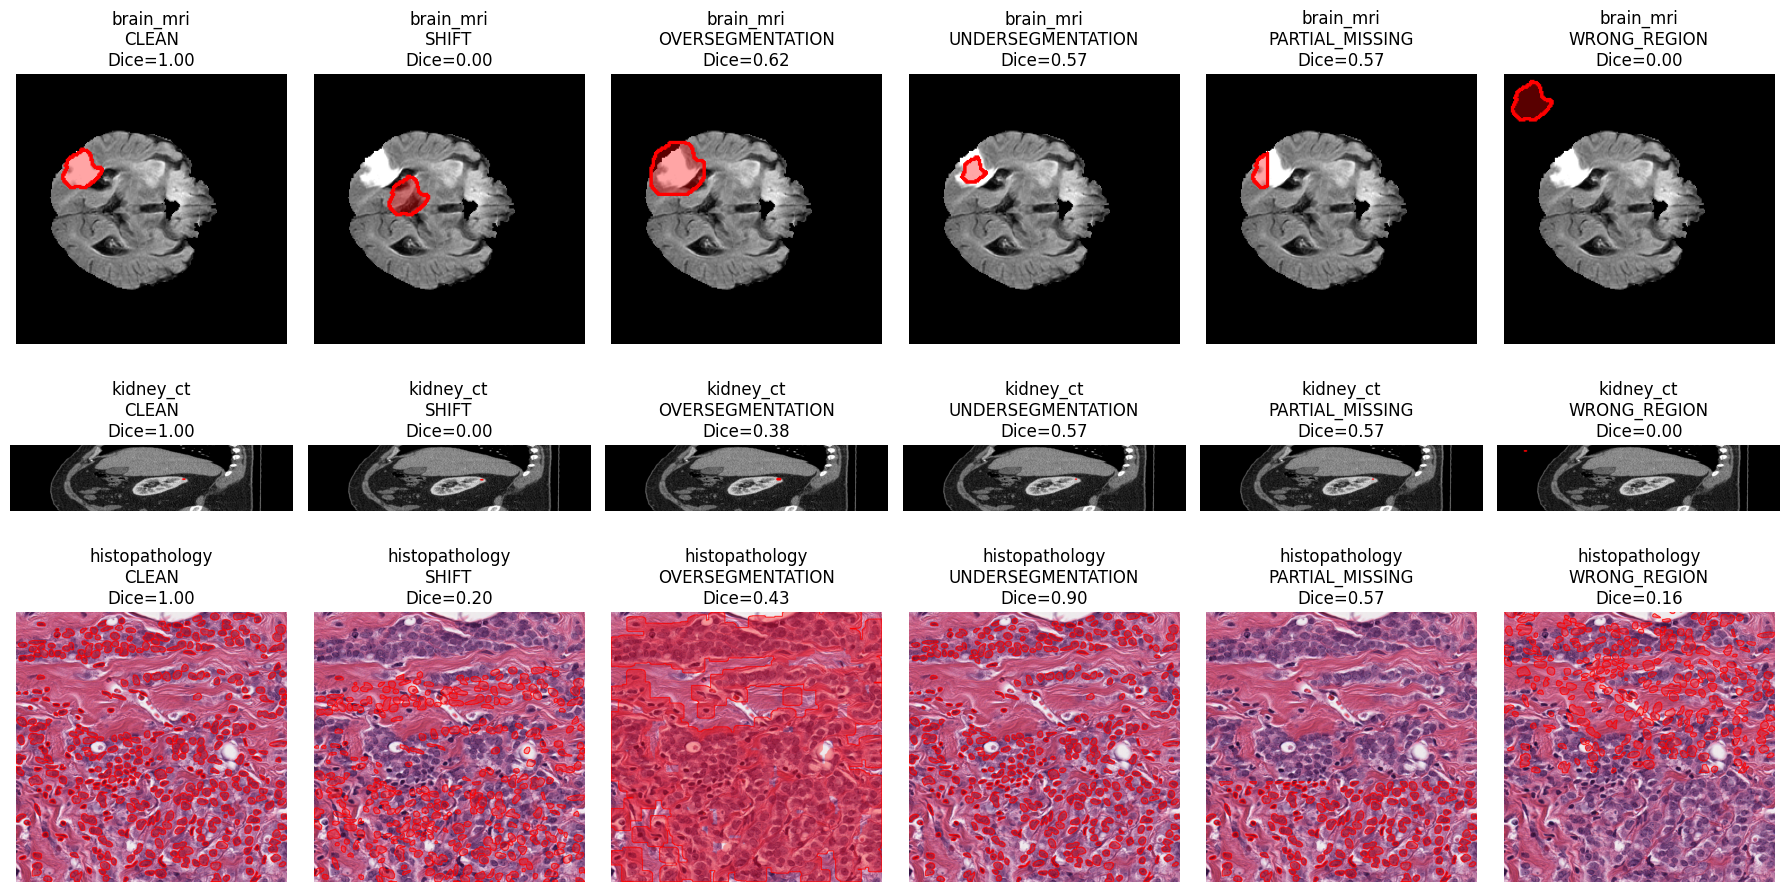

Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/06_figures/04_counterfactual_qc_qwen25vl7b_counterfactual_examples.png


In [8]:
# CELL 6 — Visual construction QA
fig,axes=plt.subplots(3,6,figsize=(18,9))
for i,domain in enumerate(['brain_mri','kidney_ct','histopathology']):
    bid=cf_labels[cf_labels['domain']==domain]['base_id'].iloc[0]
    sub=cf_labels[(cf_labels['domain']==domain)&(cf_labels['base_id']==bid)].set_index('condition')
    for j,cond in enumerate(CONDITIONS):
        rr=sub.loc[cond]; img=read_rgb(rr['vlm_overlay_path'])
        axes[i,j].imshow(img); axes[i,j].set_title(f"{domain}\n{cond}\nDice={rr['reference_dice']:.2f}"); axes[i,j].axis('off')
plt.tight_layout()
QA_FIG=FIG_DIR/f'{EXPERIMENT_ID}_counterfactual_examples.png'
plt.savefig(QA_FIG,dpi=200,bbox_inches='tight'); plt.show()
print('Saved:',QA_FIG)

In [9]:
# CELL 7 — Create blinded inference manifest
blind=cf_labels[['cf_id','domain','vlm_overlay_path']].copy()
blind['domain_text']=blind['domain'].map(lambda x: DOMAIN_TARGET[x]['domain_text'])
blind['target_text']=blind['domain'].map(lambda x: DOMAIN_TARGET[x]['target_text'])
blind=blind.sample(frac=1.0,random_state=SEED).reset_index(drop=True)
if MAX_CASES is not None: blind=blind.head(int(MAX_CASES)).copy()
BLIND_PATH=OUTPUT_DIR/f'{EXPERIMENT_ID}_blinded_manifest.csv'
blind.to_csv(BLIND_PATH,index=False)
print('Blinded cases:',len(blind)); display(blind.head())

Blinded cases: 270


,cf_id,domain,vlm_overlay_path,domain_text,target_text
0,CF_0075,brain_mri,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,brain MRI,brain tumor
1,CF_0132,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,kidney CT,kidney tumor
2,CF_0259,histopathology,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,H&E histopathology,cell nuclei
3,CF_0184,histopathology,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,H&E histopathology,cell nuclei
4,CF_0197,histopathology,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,H&E histopathology,cell nuclei


In [10]:
# CELL 8 — Structured counterfactual-QC prompt and parser
def build_prompt(domain_text,target_text):
    return f"""
You are performing quality control of a candidate medical-image segmentation.

Image domain: {domain_text}
Intended segmentation target: {target_text}

The RED overlay/outline is the candidate segmentation.
Judge only the visible relationship between the red segmentation and the medical image.

First decide whether the candidate segmentation is CLEAN or CORRUPTED.
If it is corrupted, identify the single best visible error type from:
SHIFT, OVERSEGMENTATION, UNDERSEGMENTATION, PARTIAL_MISSING, WRONG_REGION, OTHER.

Return ONLY one valid JSON object with exactly these fields:
{{
  "qc_label": "CLEAN|CORRUPTED",
  "corruption_probability": 0,
  "error_type": "NONE|SHIFT|OVERSEGMENTATION|UNDERSEGMENTATION|PARTIAL_MISSING|WRONG_REGION|OTHER",
  "grounding": "one concise sentence describing the visible image-mask relationship"
}}

Rules:
- corruption_probability must be an integer from 0 to 100.
- If qc_label is CLEAN, error_type must be NONE.
- If qc_label is CORRUPTED, error_type must not be NONE.
- Do not give a diagnosis.
- Do not discuss Dice, IoU, ground truth, or unseen information.
- grounding must be no more than 35 words.
- Output JSON only; no markdown.
""".strip()

ALLOWED_QC={'CLEAN','CORRUPTED'}
ALLOWED_TYPES={'NONE','SHIFT','OVERSEGMENTATION','UNDERSEGMENTATION','PARTIAL_MISSING','WRONG_REGION','OTHER'}
def extract_json(text):
    text=str(text).strip(); text=re.sub(r'^```(?:json)?\s*','',text,flags=re.I); text=re.sub(r'\s*```$','',text)
    try:
        obj=json.loads(text)
        if isinstance(obj,dict): return obj
    except: pass
    m=re.search(r'\{.*\}',text,flags=re.S)
    if m:
        try:
            obj=json.loads(m.group(0))
            if isinstance(obj,dict): return obj
        except: pass
    return None

def normalize(raw):
    obj=extract_json(raw); out={'parse_ok':False,'qc_label':None,'corruption_probability':np.nan,'error_type':None,'grounding':None}
    if obj is None: return out
    qc=str(obj.get('qc_label','')).strip().upper(); et=str(obj.get('error_type','')).strip().upper(); g=str(obj.get('grounding','')).strip()
    try: p=int(round(float(obj.get('corruption_probability'))))
    except: p=None
    if qc not in ALLOWED_QC or et not in ALLOWED_TYPES or p is None or not (0<=p<=100) or not g: return out
    if qc=='CLEAN' and et!='NONE': return out
    if qc=='CORRUPTED' and et=='NONE': return out
    out.update({'parse_ok':True,'qc_label':qc,'corruption_probability':p,'error_type':et,'grounding':g}); return out

print(build_prompt('brain MRI','brain tumor'))

You are performing quality control of a candidate medical-image segmentation.

Image domain: brain MRI
Intended segmentation target: brain tumor

The RED overlay/outline is the candidate segmentation.
Judge only the visible relationship between the red segmentation and the medical image.

First decide whether the candidate segmentation is CLEAN or CORRUPTED.
If it is corrupted, identify the single best visible error type from:
SHIFT, OVERSEGMENTATION, UNDERSEGMENTATION, PARTIAL_MISSING, WRONG_REGION, OTHER.

Return ONLY one valid JSON object with exactly these fields:
{
  "qc_label": "CLEAN|CORRUPTED",
  "corruption_probability": 0,
  "error_type": "NONE|SHIFT|OVERSEGMENTATION|UNDERSEGMENTATION|PARTIAL_MISSING|WRONG_REGION|OTHER",
  "grounding": "one concise sentence describing the visible image-mask relationship"
}

Rules:
- corruption_probability must be an integer from 0 to 100.
- If qc_label is CLEAN, error_type must be NONE.
- If qc_label is CORRUPTED, error_type must not be NONE.

In [11]:
# CELL 9 — Load Qwen2.5-VL-7B and define single-case inference
print('Loading:',MODEL_ID); t0=time.time()
model=Qwen2_5_VLForConditionalGeneration.from_pretrained(MODEL_ID,torch_dtype=torch.bfloat16,device_map='auto')
processor=AutoProcessor.from_pretrained(MODEL_ID,min_pixels=MIN_PIXELS,max_pixels=MAX_PIXELS)
model.eval(); print(f'Loaded in {(time.time()-t0)/60:.1f} min'); print('Commit:',getattr(model.config,'_commit_hash',None))

def run_case(row):
    uri=Path(str(row['vlm_overlay_path'])).resolve().as_uri()
    messages=[{'role':'user','content':[{'type':'image','image':uri},{'type':'text','text':build_prompt(str(row['domain_text']),str(row['target_text']))}]}]
    txt=processor.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    image_inputs,video_inputs=process_vision_info(messages)
    inputs=processor(text=[txt],images=image_inputs,videos=video_inputs,padding=True,return_tensors='pt').to(model.device)
    t=time.time()
    with torch.inference_mode():
        ids=model.generate(**inputs,max_new_tokens=MAX_NEW_TOKENS,do_sample=False,use_cache=True)
    ids=ids[:,inputs.input_ids.shape[1]:]
    raw=processor.batch_decode(ids,skip_special_tokens=True,clean_up_tokenization_spaces=False)[0].strip(); p=normalize(raw)
    out={'cf_id':str(row['cf_id']),'domain':str(row['domain']),'model_id':MODEL_ID,'prompt_version':PROMPT_VERSION,
         'raw_output':raw,'parse_ok':bool(p['parse_ok']),'qc_label':p['qc_label'],
         'corruption_probability':None if pd.isna(p['corruption_probability']) else int(p['corruption_probability']),
         'error_type':p['error_type'],'grounding':p['grounding'],'generation_seconds':float(time.time()-t),
         'timestamp_utc':datetime.now(timezone.utc).isoformat()}
    del inputs,ids,image_inputs,video_inputs
    return out

smoke=run_case(blind.iloc[0]); print(json.dumps(smoke,indent=2))
if not smoke['parse_ok']: raise RuntimeError('Structured-output smoke test failed.')

`torch_dtype` is deprecated! Use `dtype` instead!


Loading: Qwen/Qwen2.5-VL-7B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loaded in 0.9 min
Commit: cc594898137f460bfe9f0759e9844b3ce807cfb5
{
  "cf_id": "CF_0075",
  "domain": "brain_mri",
  "model_id": "Qwen/Qwen2.5-VL-7B-Instruct",
  "prompt_version": "counterfactual_v1.0",
  "raw_output": "{\n  \"qc_label\": \"CORRUPTED\",\n  \"corruption_probability\": 70,\n  \"error_type\": \"OVERSEGMENTATION\",\n  \"grounding\": \"The red segmentation extends beyond the actual tumor boundaries, oversegmenting the region.\"\n}",
  "parse_ok": true,
  "qc_label": "CORRUPTED",
  "corruption_probability": 70,
  "error_type": "OVERSEGMENTATION",
  "grounding": "The red segmentation extends beyond the actual tumor boundaries, oversegmenting the region.",
  "generation_seconds": 4.710293531417847,
  "timestamp_utc": "2026-08-08T04:01:24.105926+00:00"
}


In [12]:
# CELL 10 — Run/resume all 270 blinded cases
PRED_JSONL=OUTPUT_DIR/f'{EXPERIMENT_ID}_predictions.jsonl'
def completed(path):
    out=set()
    if not Path(path).exists(): return out
    with open(path,'r',encoding='utf-8') as f:
        for line in f:
            try: out.add(str(json.loads(line)['cf_id']))
            except: pass
    return out
if OVERWRITE_EXISTING and PRED_JSONL.exists(): PRED_JSONL.unlink()
done=completed(PRED_JSONL); errors=[]; print('Previously completed:',len(done))
for i,(_,row) in enumerate(tqdm(blind.iterrows(),total=len(blind),desc='Qwen counterfactual QC'),start=1):
    cid=str(row['cf_id'])
    if cid in done: continue
    try:
        result=run_case(row)
        with open(PRED_JSONL,'a',encoding='utf-8') as f:
            f.write(json.dumps(result,ensure_ascii=False)+'\n'); f.flush()
        done.add(cid)
    except Exception as e:
        errors.append({'cf_id':cid,'domain':row['domain'],'error':repr(e)})
    if i%20==0: gc.collect(); torch.cuda.empty_cache()
print('Completed:',len(done),'Errors:',len(errors))
if errors:
    edf=pd.DataFrame(errors); display(edf); edf.to_csv(LOG_DIR/f'{EXPERIMENT_ID}_runtime_errors.csv',index=False)

Previously completed: 0


Qwen counterfactual QC:   0%|          | 0/270 [00:00<?, ?it/s]

Completed: 270 Errors: 0


In [13]:
# CELL 11 — Load predictions and merge hidden labels after inference
rows=[]
with open(PRED_JSONL,'r',encoding='utf-8') as f:
    for line in f:
        if line.strip(): rows.append(json.loads(line))
pred=pd.DataFrame(rows).sort_values('timestamp_utc').drop_duplicates('cf_id',keep='last')
pred=pred[pred['cf_id'].isin(blind['cf_id'])].copy()
PRED_CSV=OUTPUT_DIR/f'{EXPERIMENT_ID}_predictions.csv'; pred.to_csv(PRED_CSV,index=False)
print('Unique predictions:',len(pred),'/',len(blind)); print('Parse success:',f"{pred['parse_ok'].mean()*100:.1f}%")
display(pred['qc_label'].value_counts(dropna=False).rename_axis('qc_label').reset_index(name='n'))

ev=pred.merge(cf_labels[['cf_id','domain','base_id','source_benchmark_id','condition','is_corrupted','reference_dice','reference_iou','dice_degradation','area_ratio_vs_reference']],on=['cf_id','domain'],how='inner',validate='one_to_one')
valid=ev[ev['parse_ok']==True].copy(); valid['pred_corrupted']=valid['qc_label']=='CORRUPTED'; valid['corruption_score']=pd.to_numeric(valid['corruption_probability'],errors='coerce')/100.0
valid['true_error_type']=valid['condition'].replace({'CLEAN':'NONE'})
CASE_PATH=EVAL_DIR/f'{EXPERIMENT_ID}_case_level_evaluation.csv'; valid.to_csv(CASE_PATH,index=False)
print('Evaluable:',len(valid))

Unique predictions: 270 / 270
Parse success: 100.0%


,qc_label,n
0,CORRUPTED,233
1,CLEAN,37


Evaluable: 270


In [14]:
# CELL 12 — Primary metrics, type recognition, and stratified results
def bin_metrics(df):
    y=df['is_corrupted'].astype(int).to_numpy(); p=df['pred_corrupted'].astype(int).to_numpy(); s=df['corruption_score'].astype(float).to_numpy()
    tn,fp,fn,tp=confusion_matrix(y,p,labels=[0,1]).ravel()
    out={'n':len(df),'accuracy':accuracy_score(y,p),'balanced_accuracy':balanced_accuracy_score(y,p),
         'precision':precision_score(y,p,zero_division=0),'sensitivity':recall_score(y,p,zero_division=0),
         'specificity':tn/(tn+fp) if tn+fp else np.nan,'f1':f1_score(y,p,zero_division=0),
         'false_reassurance_rate':fn/(fn+tp) if fn+tp else np.nan,'false_alarm_rate':fp/(fp+tn) if fp+tn else np.nan,
         'tp':int(tp),'tn':int(tn),'fp':int(fp),'fn':int(fn)}
    if len(np.unique(y))==2 and np.isfinite(s).all():
        out.update({'auroc':roc_auc_score(y,s),'auprc':average_precision_score(y,s),'brier':brier_score_loss(y,s)})
    else: out.update({'auroc':np.nan,'auprc':np.nan,'brier':np.nan})
    return out

overall=bin_metrics(valid)
TYPE_LABELS=['NONE','SHIFT','OVERSEGMENTATION','UNDERSEGMENTATION','PARTIAL_MISSING','WRONG_REGION','OTHER']
type_accuracy=accuracy_score(valid['true_error_type'],valid['error_type'])
type_macro_f1=f1_score(valid['true_error_type'],valid['error_type'],labels=TYPE_LABELS,average='macro',zero_division=0)
corrupt=valid[valid['is_corrupted']==True]
corrupt_type_accuracy=accuracy_score(corrupt['condition'],corrupt['error_type'])
corrupt_type_macro_f1=f1_score(corrupt['condition'],corrupt['error_type'],labels=['SHIFT','OVERSEGMENTATION','UNDERSEGMENTATION','PARTIAL_MISSING','WRONG_REGION'],average='macro',zero_division=0)

drows=[]
for d,ddf in valid.groupby('domain'):
    m=bin_metrics(ddf); m['domain']=d; m['corrupted_type_accuracy']=accuracy_score(ddf[ddf['is_corrupted']]['condition'],ddf[ddf['is_corrupted']]['error_type']); drows.append(m)
domain_metrics=pd.DataFrame(drows); domain_metrics.to_csv(EVAL_DIR/f'{EXPERIMENT_ID}_domain_metrics.csv',index=False)

crows=[]
for c,ddf in valid.groupby('condition'):
    if c=='CLEAN': qc=float((ddf['qc_label']=='CLEAN').mean()); ta=float((ddf['error_type']=='NONE').mean())
    else: qc=float(ddf['pred_corrupted'].mean()); ta=float((ddf['error_type']==c).mean())
    crows.append({'condition':c,'n':len(ddf),'mean_reference_dice':ddf['reference_dice'].mean(),'mean_corruption_probability':ddf['corruption_score'].mean(),'correct_binary_qc_rate':qc,'correct_error_type_rate':ta})
condition_metrics=pd.DataFrame(crows); condition_metrics.to_csv(EVAL_DIR/f'{EXPERIMENT_ID}_condition_metrics.csv',index=False)

display(pd.DataFrame([overall])); display(condition_metrics.sort_values('condition')); display(domain_metrics)

,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier
0,270,0.8,0.604444,0.866953,0.897778,0.311111,0.882096,0.102222,0.688889,202,14,31,23,0.604444,0.863516,0.208778


,condition,n,mean_reference_dice,mean_corruption_probability,correct_binary_qc_rate,correct_error_type_rate
0,CLEAN,45,1.000000,0.482222,0.311111,0.311111
1,OVERSEGMENTATION,45,0.520893,0.653333,0.933333,0.777778
2,PARTIAL_MISSING,45,0.572361,0.700000,1.000000,0.000000
3,SHIFT,45,0.076110,0.575556,0.822222,0.000000
4,UNDERSEGMENTATION,45,0.582570,0.528889,0.755556,0.133333
5,WRONG_REGION,45,0.062371,0.684444,0.977778,0.200000


,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier,domain,corrupted_type_accuracy
0,90,0.833333,0.500000,0.833333,1.000000,0.000000,0.909091,0.000000,1.000000,75,0,15,0,0.500000,0.833333,0.156667,brain_mri,0.293333
1,90,0.733333,0.813333,0.981132,0.693333,0.933333,0.812500,0.306667,0.066667,52,14,1,23,0.813333,0.935807,0.313000,histopathology,0.173333
2,90,0.833333,0.500000,0.833333,1.000000,0.000000,0.909091,0.000000,1.000000,75,0,15,0,0.500000,0.833333,0.156667,kidney_ct,0.200000


In [15]:
# CELL 13 — Bootstrap CIs and risk-vs-severity association
def boot_ci(metric,n_boot=2000):
    rng=np.random.default_rng(SEED); vals=[]; n=len(valid)
    for _ in range(n_boot):
        b=valid.iloc[rng.integers(0,n,size=n)]
        try:
            v=bin_metrics(b)[metric]
            if np.isfinite(v): vals.append(v)
        except: pass
    return (float(np.percentile(vals,2.5)),float(np.percentile(vals,97.5))) if vals else (np.nan,np.nan)

ci=[]
for m in ['balanced_accuracy','sensitivity','specificity','f1','false_reassurance_rate','auroc','auprc','brier']:
    lo,hi=boot_ci(m); ci.append({'metric':m,'estimate':overall[m],'ci95_low':lo,'ci95_high':hi})
ci=pd.DataFrame(ci); ci.to_csv(EVAL_DIR/f'{EXPERIMENT_ID}_bootstrap_95ci.csv',index=False); display(ci)

rho,pval=spearmanr(valid['corruption_score'],valid['dice_degradation'],nan_policy='omit')
assoc=pd.DataFrame([{'n':len(valid),'spearman_rho_corruption_probability_vs_dice_degradation':rho,'p_value':pval}])
assoc.to_csv(EVAL_DIR/f'{EXPERIMENT_ID}_risk_severity_association.csv',index=False); display(assoc)

,metric,estimate,ci95_low,ci95_high
0,balanced_accuracy,0.604444,0.536965,0.673661
1,sensitivity,0.897778,0.857778,0.937507
2,specificity,0.311111,0.181773,0.444444
3,f1,0.882096,0.848758,0.910265
4,false_reassurance_rate,0.102222,0.062493,0.142222
5,auroc,0.604444,0.536965,0.673661
6,auprc,0.863516,0.819410,0.903990
7,brier,0.208778,0.177185,0.243224


,n,spearman_rho_corruption_probability_vs_dice_degradation,p_value
0,270,0.278587,0.000003


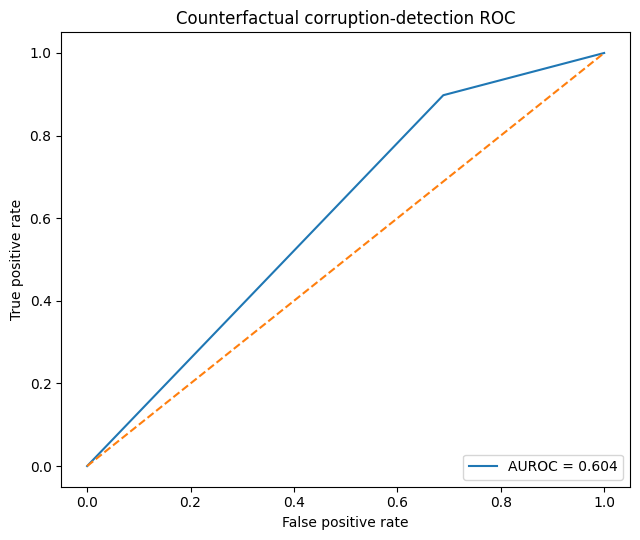

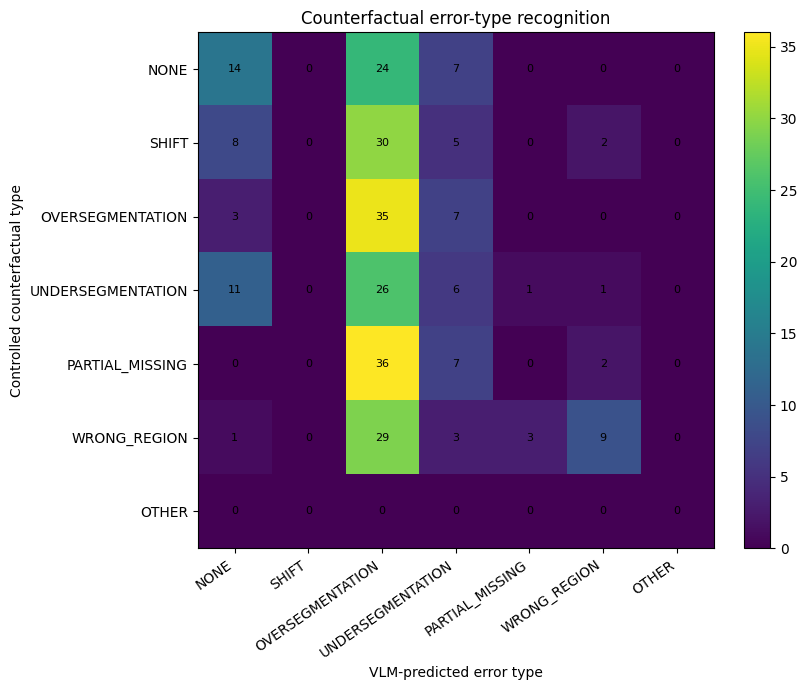

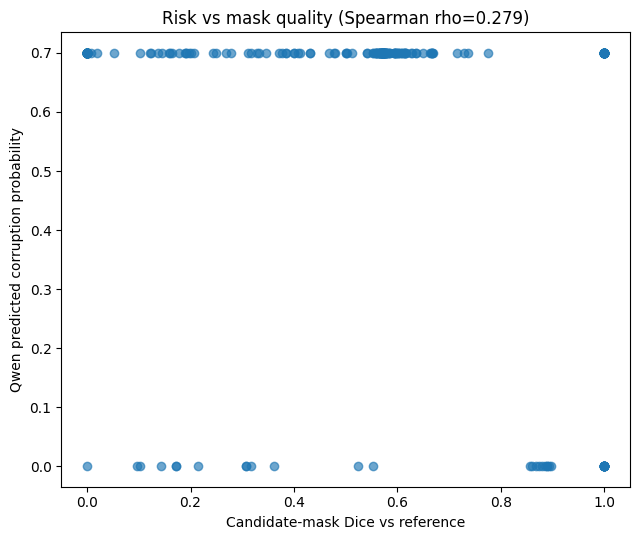

In [16]:
# CELL 14 — Publication figures
# ROC
Y=valid['is_corrupted'].astype(int).to_numpy(); S=valid['corruption_score'].to_numpy()
if len(np.unique(Y))==2:
    fpr,tpr,_=roc_curve(Y,S); auc=roc_auc_score(Y,S)
    fig,ax=plt.subplots(figsize=(6.5,5.5)); ax.plot(fpr,tpr,label=f'AUROC = {auc:.3f}'); ax.plot([0,1],[0,1],linestyle='--')
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate'); ax.set_title('Counterfactual corruption-detection ROC'); ax.legend(loc='lower right'); plt.tight_layout()
    plt.savefig(FIG_DIR/f'{EXPERIMENT_ID}_roc.png',dpi=220,bbox_inches='tight'); plt.show()

# Type confusion matrix
order=['NONE','SHIFT','OVERSEGMENTATION','UNDERSEGMENTATION','PARTIAL_MISSING','WRONG_REGION','OTHER']
cm=confusion_matrix(valid['true_error_type'],valid['error_type'],labels=order)
fig,ax=plt.subplots(figsize=(9,7)); im=ax.imshow(cm); ax.set_xticks(range(len(order))); ax.set_yticks(range(len(order))); ax.set_xticklabels(order,rotation=35,ha='right'); ax.set_yticklabels(order)
ax.set_xlabel('VLM-predicted error type'); ax.set_ylabel('Controlled counterfactual type'); ax.set_title('Counterfactual error-type recognition')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]): ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,fraction=.046,pad=.04); plt.tight_layout(); plt.savefig(FIG_DIR/f'{EXPERIMENT_ID}_error_type_confusion_matrix.png',dpi=220,bbox_inches='tight'); plt.show()

# Risk vs objective Dice
fig,ax=plt.subplots(figsize=(6.5,5.5)); ax.scatter(valid['reference_dice'],valid['corruption_score'],alpha=.65)
ax.set_xlabel('Candidate-mask Dice vs reference'); ax.set_ylabel('Qwen predicted corruption probability'); ax.set_title(f'Risk vs mask quality (Spearman rho={rho:.3f})'); plt.tight_layout()
plt.savefig(FIG_DIR/f'{EXPERIMENT_ID}_risk_vs_reference_dice.png',dpi=220,bbox_inches='tight'); plt.show()

In [17]:
# CELL 15 — False reassurance / false alarm analysis and final summary
false_reassurance=valid[(valid['is_corrupted']==True)&(valid['pred_corrupted']==False)].sort_values(['reference_dice','corruption_score'])
false_alarm=valid[(valid['is_corrupted']==False)&(valid['pred_corrupted']==True)].sort_values('corruption_score',ascending=False)
FR_PATH=EVAL_DIR/f'{EXPERIMENT_ID}_false_reassurance.csv'; FA_PATH=EVAL_DIR/f'{EXPERIMENT_ID}_clean_false_alarm.csv'
false_reassurance.to_csv(FR_PATH,index=False); false_alarm.to_csv(FA_PATH,index=False)

summary={
    'experiment_id':EXPERIMENT_ID,'model_id':MODEL_ID,'model_commit':getattr(model.config,'_commit_hash',None),'prompt_version':PROMPT_VERSION,'seed':SEED,
    'benchmark':{'base_cases':len(base),'base_cases_per_domain':BASE_CASES_PER_DOMAIN,'conditions':CONDITIONS,'counterfactual_cases':len(blind),'evaluable_cases':len(valid),'parse_success_rate':float(pred['parse_ok'].mean())},
    'primary_binary_metrics':overall,
    'error_type_metrics':{'all_case_accuracy':float(type_accuracy),'all_case_macro_f1':float(type_macro_f1),'corrupted_only_accuracy':float(corrupt_type_accuracy),'corrupted_only_macro_f1':float(corrupt_type_macro_f1)},
    'risk_severity_association':{'spearman_rho':float(rho),'p_value':float(pval)},
    'mean_generation_seconds':float(pred['generation_seconds'].mean())
}
SUMMARY_PATH=EVAL_DIR/f'{EXPERIMENT_ID}_summary.json'; SUMMARY_PATH.write_text(json.dumps(summary,indent=2))

print('='*88); print('CONTROLLED COUNTERFACTUAL QC RESULTS — QWEN2.5-VL-7B'); print('='*88)
print(f'Base cases: {len(base)}'); print(f'Counterfactual images: {len(valid)}'); print(f"Parse success: {pred['parse_ok'].mean()*100:.1f}%")
print('\nBinary CLEAN vs CORRUPTED')
for label,key in [('Balanced accuracy','balanced_accuracy'),('Sensitivity','sensitivity'),('Specificity','specificity'),('F1','f1'),('False reassurance','false_reassurance_rate'),('False alarm rate','false_alarm_rate'),('AUROC','auroc'),('AUPRC','auprc'),('Brier score','brier')]:
    print(f'  {label:18s}: {overall[key]:.3f}')
print('\nCounterfactual error-type identification')
print(f'  All-case accuracy       : {type_accuracy:.3f}'); print(f'  All-case macro F1       : {type_macro_f1:.3f}')
print(f'  Corrupted-only accuracy : {corrupt_type_accuracy:.3f}'); print(f'  Corrupted-only macro F1 : {corrupt_type_macro_f1:.3f}')
print('\nRisk vs objective Dice degradation'); print(f'  Spearman rho            : {rho:.3f}'); print(f'  p-value                 : {pval:.3g}')
print('\nPer-condition results'); display(condition_metrics.sort_values('condition'))
print('Per-domain results'); display(domain_metrics)
print('Summary saved:',SUMMARY_PATH)

CONTROLLED COUNTERFACTUAL QC RESULTS — QWEN2.5-VL-7B
Base cases: 45
Counterfactual images: 270
Parse success: 100.0%

Binary CLEAN vs CORRUPTED
  Balanced accuracy : 0.604
  Sensitivity       : 0.898
  Specificity       : 0.311
  F1                : 0.882
  False reassurance : 0.102
  False alarm rate  : 0.689
  AUROC             : 0.604
  AUPRC             : 0.864
  Brier score       : 0.209

Counterfactual error-type identification
  All-case accuracy       : 0.237
  All-case macro F1       : 0.158
  Corrupted-only accuracy : 0.222
  Corrupted-only macro F1 : 0.164

Risk vs objective Dice degradation
  Spearman rho            : 0.279
  p-value                 : 3.34e-06

Per-condition results


,condition,n,mean_reference_dice,mean_corruption_probability,correct_binary_qc_rate,correct_error_type_rate
0,CLEAN,45,1.000000,0.482222,0.311111,0.311111
1,OVERSEGMENTATION,45,0.520893,0.653333,0.933333,0.777778
2,PARTIAL_MISSING,45,0.572361,0.700000,1.000000,0.000000
3,SHIFT,45,0.076110,0.575556,0.822222,0.000000
4,UNDERSEGMENTATION,45,0.582570,0.528889,0.755556,0.133333
5,WRONG_REGION,45,0.062371,0.684444,0.977778,0.200000


Per-domain results


,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier,domain,corrupted_type_accuracy
0,90,0.833333,0.500000,0.833333,1.000000,0.000000,0.909091,0.000000,1.000000,75,0,15,0,0.500000,0.833333,0.156667,brain_mri,0.293333
1,90,0.733333,0.813333,0.981132,0.693333,0.933333,0.812500,0.306667,0.066667,52,14,1,23,0.813333,0.935807,0.313000,histopathology,0.173333
2,90,0.833333,0.500000,0.833333,1.000000,0.000000,0.909091,0.000000,1.000000,75,0,15,0,0.500000,0.833333,0.156667,kidney_ct,0.200000


Summary saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/04_counterfactual_qc_qwen25vl7b_summary.json
